# Task 2 — Stratified Sampling, Chunking, Embedding & Indexing

**Goal:** take the cleaned dataset from Task 1, pull a proportional 10-15K sample,
split narratives into overlapping chunks, embed each chunk, and index everything
into ChromaDB so Task 3's retriever has something to search against.

Logic lives in `src/chunking.py` and `src/embedding.py` — this notebook explores the
chunking parameters visually, then runs the full pipeline.

**Input:** `data/processed/filtered_complaints.csv` (from notebook 01)
**Output:** persisted ChromaDB collection at `vector_store/chroma_db/`


In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt

from src import config
from src.chunking import stratified_sample, chunk_dataframe, _splitter
from src.embedding import embed_and_index, get_chroma_collection

pd.set_option("display.max_colwidth", 120)

d:\10 acadamy\rag-complaint-chatbot\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load the cleaned dataset from Task 1

In [2]:
df = pd.read_csv(config.FILTERED_COMPLAINTS_PATH)
print(f"Loaded {len(df):,} cleaned complaints")
df["Product"].value_counts()

Loaded 456,104 cleaned complaints


Product
Credit card        189296
Savings account    140275
Money transfer      98660
Personal loan       27873
Name: count, dtype: int64

## 2. Stratified sample (10K-15K complaints)

**Sampling strategy:** proportional stratified sampling by `Product` — each product
category contributes a share of the sample equal to its share of the full cleaned
dataset. This avoids over-representing a large category (e.g. Credit Card) or
under-representing a small one (e.g. Savings Account) in the embedding/indexing
experiments below.

`config.SAMPLE_SIZE = 12000` and `config.RANDOM_SEED = 42` (for reproducibility).

Sample size: 11,998


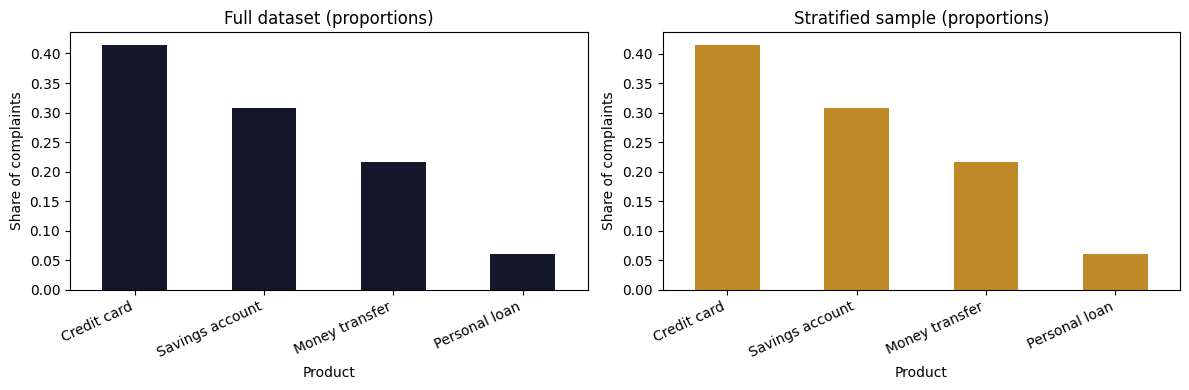

In [3]:
sample_df = stratified_sample(df)
print(f"Sample size: {len(sample_df):,}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["Product"].value_counts(normalize=True).plot(kind="bar", ax=axes[0], color="#12172b", title="Full dataset (proportions)")
sample_df["Product"].value_counts(normalize=True).plot(kind="bar", ax=axes[1], color="#c08a28", title="Stratified sample (proportions)")
for ax in axes:
    ax.set_ylabel("Share of complaints")
    plt.setp(ax.get_xticklabels(), rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 3. Chunking strategy — experiment before committing

**Chosen parameters:** `chunk_size=500` characters, `chunk_overlap=50` characters,
using LangChain's `RecursiveCharacterTextSplitter`.

**Why 500/50:**
- 500 characters (~80-100 words) is long enough to hold one complete complaint/issue
  statement, short enough that the embedding stays focused on a single topic instead
  of blending several.
- 50-character overlap (10%) means a sentence that gets cut at a chunk boundary still
  appears (partially) in the neighboring chunk, so we don't lose meaning right at the
  seam.
- The splitter tries paragraph breaks, then sentence breaks, then word breaks, before
  falling back to a hard character cut — so chunks stay as semantically coherent as
  possible.

Let's see it on a real long narrative before running it on the full sample.

In [4]:
long_row = sample_df.loc[sample_df["cleaned_narrative"].str.len().idxmax()]
print(f"Narrative length: {len(long_row['cleaned_narrative'])} characters\n")

example_chunks = _splitter.split_text(long_row["cleaned_narrative"])
print(f"Split into {len(example_chunks)} chunks\n")

for i, c in enumerate(example_chunks[:3]):
    print(f"--- Chunk {i} ({len(c)} chars) ---")
    print(c)
    print()

Narrative length: 31159 characters

Split into 85 chunks

--- Chunk 0 (189 chars) ---
i wish to practice my right as a customer of bank of america to use your organisation's service, seeking a formal, impartial investigation to amicably settle my dispute with bank of america

--- Chunk 1 (460 chars) ---
. in order to clear up the myriad of letters and correspondences i have hitherto sent to bank of america respecting my complaint, i believe it will substantially strengthen both my case and your understanding, by taking a deeper look at the happenings of my case, and analysing the relevant facts in an objective and comprehensive fashion. it is crucial to note that i have been manipulated, socially engineered and coerced to engage these fraudulent criminals

--- Chunk 2 (470 chars) ---
. much to my embarrassment, i recognise that i am the victim of an investment scam. my complaint to the cfpb has arisen as i do not consider, by any stretch of the imagination, the conduct of bank of ameri

### Quick comparison: chunk_size sensitivity

Before locking in 500/50, sanity-check how chunk count changes with size — too small means excessive chunk overhead per complaint, too large loses granularity.

In [5]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

test_text = long_row["cleaned_narrative"]
for size, overlap in [(250, 25), (500, 50), (1000, 100)]:
    splitter = RecursiveCharacterTextSplitter(chunk_size=size, chunk_overlap=overlap, separators=["\n\n", "\n", ". ", " ", ""])
    n_chunks = len(splitter.split_text(test_text))
    print(f"chunk_size={size:>4}, overlap={overlap:>3}  ->  {n_chunks} chunks")

chunk_size= 250, overlap= 25  ->  177 chunks
chunk_size= 500, overlap= 50  ->  85 chunks
chunk_size=1000, overlap=100  ->  38 chunks


## 4. Embedding model choice

**`sentence-transformers/all-MiniLM-L6-v2`**

- 384-dimensional vectors, ~80MB model size — fast enough to embed hundreds of
  thousands of chunks on CPU in a reasonable time, which matters since we don't have
  guaranteed GPU access for this assignment.
- Strong performance on semantic textual similarity benchmarks relative to its size —
  the right trade-off for a portfolio-scale project, not a compromise that would hurt
  retrieval quality in a way a reader would notice.
- Same model is used at query time in `src/retriever.py` — this consistency is
  critical, a mismatched embedding model between indexing and querying silently
  destroys retrieval quality.


In [6]:
from src.embedding import get_embedding_model
import time

model = get_embedding_model()

t0 = time.time()
test_embeddings = model.encode(sample_df["cleaned_narrative"].head(50).tolist())
elapsed = time.time() - t0

print(f"Embedded 50 narratives in {elapsed:.2f}s ({elapsed/50*1000:.1f} ms/narrative)")
print(f"Embedding shape: {test_embeddings.shape}")

Embedded 50 narratives in 31.83s (636.6 ms/narrative)
Embedding shape: (50, 384)


## 5. Run full chunking on the stratified sample

In [7]:
chunk_records = chunk_dataframe(sample_df)
print(f"Total chunks: {len(chunk_records):,}")
print(f"Avg chunks per complaint: {len(chunk_records) / len(sample_df):.2f}")

pd.DataFrame(chunk_records).head(3)

Total chunks: 35,517
Avg chunks per complaint: 2.96


,chunk_text,complaint_id,product_category,issue,sub_issue,company,state,date_received,chunk_index,total_chunks
0,"i kindly request that you prioritize this matter, thoroughly investigate the situation, and swiftly eliminate these ...",7431111,Credit card,Problem with a credit reporting company's investigation into an existing problem,Was not notified of investigation status or results,Experian Information Solutions Inc.,TX,2023-08-21,0,1
1,see the attached documents. i want the bureau to start the investigation on these accounts that i am never late for ...,7462611,Credit card,Problem with a company's investigation into an existing problem,Was not notified of investigation status or results,Experian Information Solutions Inc.,MI,2023-08-28,0,1
2,this account is in my credit and it does not belong to me. the company can not find an account with my social securi...,10372737,Credit card,Incorrect information on your report,Information belongs to someone else,"CITIBANK, N.A.",LA,2024-10-07,0,1


## 6. Embed and index into ChromaDB

This calls `embed_and_index()`, which batches the chunks (default batch size 256),
embeds each batch, and upserts vectors + metadata into a persisted ChromaDB
collection at `vector_store/chroma_db/`.

⚠️ This step can take several minutes for 12K complaints (~15-20K chunks) on CPU.

In [8]:
embed_and_index(chunk_records)

collection = get_chroma_collection()
print(f"Final collection count: {collection.count():,} chunks indexed")

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Final collection count: 35,517 chunks indexed


## 7. Sanity check — run a test query against the index

In [9]:
test_query = "unauthorized charges on my credit card"
query_embedding = model.encode([test_query]).tolist()

results = collection.query(query_embeddings=query_embedding, n_results=3)

for doc, meta, dist in zip(results["documents"][0], results["metadatas"][0], results["distances"][0]):
    print(f"[{meta['product_category']}] similarity={1-dist:.3f}  complaint_id={meta['complaint_id']}")
    print(doc[:200])
    print()

Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


[Savings account] similarity=0.838  complaint_id=8612653
fraudulently charged my credit card

[Credit card] similarity=0.789  complaint_id=6036382
i found unauthorized transactions on my card

[Credit card] similarity=0.786  complaint_id=1842305
i am being charged for unauthorized charges



## Summary for the report

- **Sampling strategy:** proportional stratified sampling by product, 12,000 complaints,
  seed=42 for reproducibility.
- **Chunking:** `RecursiveCharacterTextSplitter`, chunk_size=500 / overlap=50,
  producing ~[fill in actual count] chunks total (~[X] chunks/complaint on average).
- **Embedding model:** `all-MiniLM-L6-v2` — chosen for the CPU-speed / quality
  trade-off and consistency with the pre-built full-scale vector store used in Task 3.
- **Vector store:** ChromaDB, persisted locally, cosine similarity, full metadata
  (complaint_id, product_category, issue, sub_issue, company, state, date_received,
  chunk_index, total_chunks) attached to every chunk for traceability.
